# Notebook exploring different datasets and drawing their euler angles

In [1]:
import os
from pathlib import Path

os.chdir(Path(os.getcwd()).parent.parent)

In [2]:
import math

import cv2
import numpy as np


def draw_axis(img, yaw, pitch, roll, tdx=None, tdy=None, size=100):
  """Takes a CV2 style image and draws axis on top of the image

  Args:
      img (_type_): CV2 image
      yaw (float): Yaw angle in radians
      pitch (float): Pitch angle in radians
      roll (float): rolls angle in radians
      tdx (int, optional): X translation of the axis on the image. Defaults to None.
      tdy (int, optional): Y translation of the axis on the image. Defaults to None.
      size (int, optional): Size of the axis lines. Defaults to 100.

  Returns:
      _type_: _description_
  """

  if tdx != None and tdy != None:
    tdx = tdx
    tdy = tdy
  else:
    height, width = img.shape[:2]
    tdx = width / 2
    tdy = height / 2

  # X-Axis pointing to right. drawn in blue
  x1 = size * (math.cos(yaw) * math.cos(roll)) + tdx
  y1 = size * (math.cos(pitch) * math.sin(roll) + math.cos(roll) * math.sin(pitch) * math.sin(yaw)) + tdy

  # Y-Axis | drawn in green
  #        v
  x2 = size * (-math.cos(yaw) * math.sin(roll)) + tdx
  y2 = size * (math.cos(pitch) * math.cos(roll) - math.sin(pitch) * math.sin(yaw) * math.sin(roll)) + tdy

  # Z-Axis (out of the screen) drawn in red
  x3 = size * (math.sin(yaw)) + tdx
  y3 = size * (-math.cos(yaw) * math.sin(pitch)) + tdy

  cv2.line(img, (int(tdx), int(tdy)), (int(x1), int(y1)), (0, 0, 255), 3)
  cv2.line(img, (int(tdx), int(tdy)), (int(x2), int(y2)), (0, 255, 0), 3)
  cv2.line(img, (int(tdx), int(tdy)), (int(x3), int(y3)), (255, 0, 0), 3)

  return img

# UPNA Dataset

yaw: 2.1025
pitch: -1.1536
roll: -2.0002


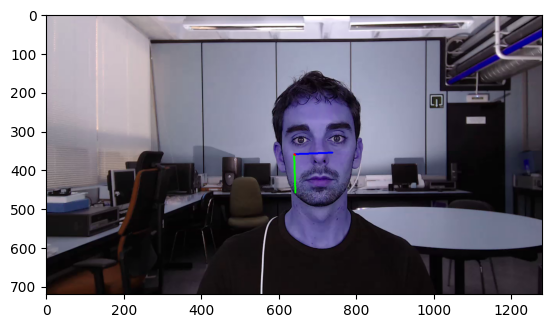

In [11]:
import math

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline


video_path = "data/raw/Head_Pose_Database_UPNA/User_01/user_01_video_01.mp4"
ground_truth_path = "data/raw/Head_Pose_Database_UPNA/User_01/user_01_video_01_groundtruth3D.txt"

ground_truth_headers = ["translation_x", "translation_y", "translation_z", "roll", "yaw", "pitch"]

video_capture = cv2.VideoCapture(video_path)
ground_truth = pd.read_csv(ground_truth_path, sep="\t", header=None, names=ground_truth_headers, index_col=False)

ret, frame = video_capture.read()

plotted_image = draw_axis(
  img=frame,
  yaw=math.radians(ground_truth.iloc[0]["yaw"]),  # Converting angles to radians
  pitch=math.radians(ground_truth.iloc[0]["pitch"]),
  roll=math.radians(ground_truth.iloc[0]["roll"]),
)

print(f"yaw: {ground_truth.iloc[0]['yaw']}")
print(f"pitch: {ground_truth.iloc[0]['pitch']}")
print(f"roll: {ground_truth.iloc[0]['roll']}")

video_capture.release()
cv2.destroyAllWindows()

plt.imshow(plotted_image)
plt.show()

# 300WLP Dataset

In [12]:
from scipy.io import loadmat


def draw_axis_over_img(img_name):
  image = cv2.imread(f"data/raw/300W_LP/AFW/{img_name}.jpg")
  image_data = loadmat(f"data/raw/300W_LP/AFW/{img_name}.mat")

  p, y, r = image_data["Pose_Para"][0, :3]
  y = -y

  print(f"converted angles:")
  print(f"pitch: {math.degrees(p)}")
  print(f"roll: {math.degrees(r)}")
  print(f"yaw: {math.degrees(y)}")

  plotted_image = draw_axis(image, y, p, r, tdx=200, tdy=200, size=100)
  plt.imshow(plotted_image)
  plt.show()

converted angles:
pitch: -6.1849945599745375
roll: 11.18050569957583
yaw: 12.858785631485514


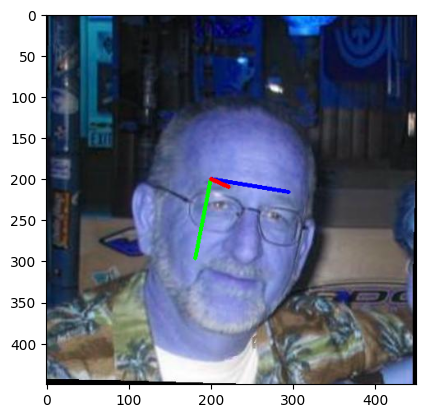

In [13]:
draw_axis_over_img("AFW_261068_1_1")

converted angles:
pitch: -8.197683541855806
roll: 9.40307703412695
yaw: 32.858786757218645


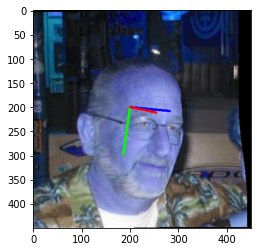

In [91]:
draw_axis_over_img("AFW_261068_1_5")

converted angles:
pitch: -19.86501951226076
roll: -9.648687221586023
yaw: -86.86726110957095


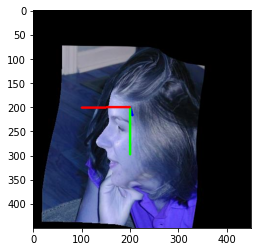

In [92]:
draw_axis_over_img("AFW_134212_1_12")

converted angles:
pitch: -19.44305042533737
roll: -11.721906620552414
yaw: -31.867261855786236


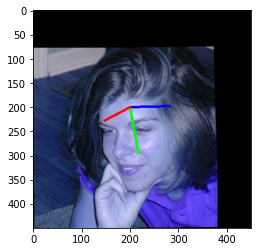

In [93]:
draw_axis_over_img("AFW_134212_1_1")

converted angles:
pitch: -8.126044248972482
roll: -21.770729375606233
yaw: -5.544546077635836


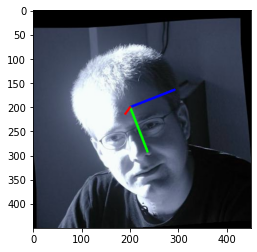

In [94]:
draw_axis_over_img("AFW_3989161_1_1")

converted angles:
pitch: -38.70036751657458
roll: -2.061708182337393
yaw: 7.235629199144708


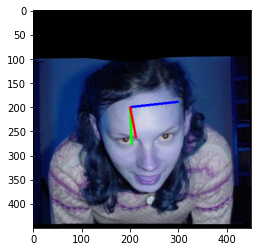

In [95]:
draw_axis_over_img("AFW_4821642_1_1")

converted angles:
pitch: -3.2253337871734384
roll: -12.685010251074756
yaw: 14.84187300039077


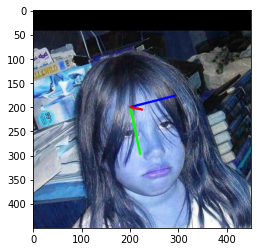

In [96]:
draw_axis_over_img("AFW_899545263_1_0")